In [1]:
import tensorflow as tf
import numpy as np

from helpers import *
from tests import *

2026-05-06 15:28:23.465907: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778095703.486701  219410 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778095703.493541  219410 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-06 15:28:23.514484: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Import dataset
from tensorflow.keras.datasets import cifar10

# Load dataset into training and testing sets
(X_train, y_train), (X_test, y_test) = cifar10.load_data()


## Visualizing the dataset

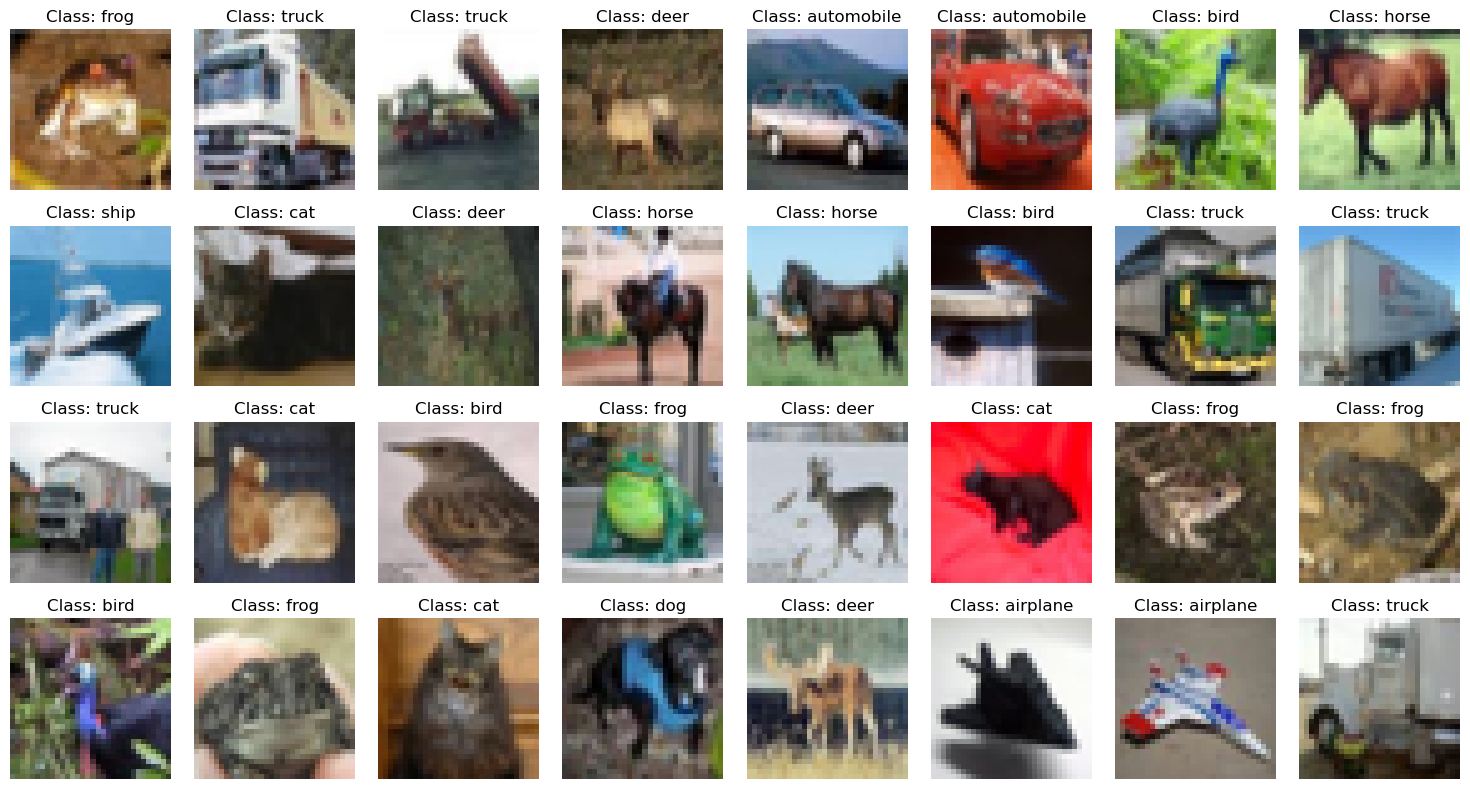

In [3]:
import matplotlib.pyplot as plt

# Visualize a grid of images from the training set
display_image_grid(X_train[:32], y_train[:32])


In [4]:
print(X_train.shape[0])


50000


In [5]:
print(X_test.shape[0])


10000


In [6]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [7]:
# TODO

num_classes = len(np.unique(y_train))
for cls in range(num_classes):
  count = 0
  
  count = np.sum(y_train == cls)
  
  print("Number of images belonging to {} is {}".format(cls, count))

Number of images belonging to 0 is 5000
Number of images belonging to 1 is 5000
Number of images belonging to 2 is 5000
Number of images belonging to 3 is 5000
Number of images belonging to 4 is 5000
Number of images belonging to 5 is 5000
Number of images belonging to 6 is 5000
Number of images belonging to 7 is 5000
Number of images belonging to 8 is 5000
Number of images belonging to 9 is 5000




---



In [8]:
# TODO

def data_preprocessing(X_train, X_test, y_train, y_test):

    """Preprocesses the training and testing data for a machine learning model.

    Args:
        X_train: Training dataset features.
        X_test: Testing dataset features.
        y_train: Training dataset labels.
        y_test: Testing dataset labels.

    Returns:
        X_train: Preprocessed training dataset features.
        X_test: Preprocessed testing dataset features.
        y_train: Preprocessed training dataset labels.
        y_test: Preprocessed testing dataset labels.

    """

    # Data Normalization
    
    X_train = X_train / 255.0
    X_test = X_test / 255.0

    # Flattening
    
    X_train = X_train.reshape(X_train.shape[0], -1)
    X_test = X_test.reshape(X_test.shape[0], -1)

    # One Hot Encoding
    
    y_train_oh = tf.keras.utils.to_categorical(y_train)
    y_test_oh = tf.keras.utils.to_categorical(y_test)

    
    preprocessing_tests(X_train, X_test, y_train_oh, y_test_oh)

    return X_train, X_test, y_train_oh, y_test_oh



# Model Building

Here, you shall be building a feedforward neural network with atleast 3 hidden neurons.

In [9]:
# TODO

# Import necessary modules
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

def build_model(input_shape, num_classes):
    """Builds a feedforward neural network model.

    Args:
        input_shape: Tuple specifying the input shape.
        num_classes: Number of output classes.

    Returns:
        Compiled Keras model.
    """

    model = Sequential()
    model.add(Input(input_shape))

    # Add hidden layers with ReLU activation
    model.add(Dense(1024, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    model.add(Dense(512, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    # Final output layer with 10 neurons
    model.add(Dense(10, activation='softmax'))

    # Compile the model
    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Test model structure
    test_model_structure(model)

    return model

# Model Training and Evaluation



In [10]:
np.random.seed(43)  # for reproducibility
tf.random.set_seed(43)  # for reproducibility

In [11]:
# TODO

def compile_model(model):
  """Compiles the given model.

  Args:
      model(tf.keras.Model): The model to be compiled.

  Returns:
      None
  """
  #Compile the model such that add a categorical cross entropy loss function,
  # adam optimizer and measure the performance using 'Accuracy' metric.

  
  model.compile(
      optimizer='adam',
      loss='categorical_crossentropy',
      metrics=['accuracy']
  )
     
  
  test_model_compilation(model)


In [12]:
def train_model(x_train, y_train, model, epochs, val_split, batch_sz):
    """Trains the model using the provided training data.

    Args:
        x_train: Training dataset features.
        y_train: Training dataset labels.
        model (tf.keras.Model): The compiled neural network model.
        epochs (int, optional): Number of epochs to train the model. Defaults to 10.
        val_split (float, optional): Fraction of the training data to be used as validation data. Defaults to 0.2.

    Returns:
        tf.keras.callbacks.History: The training history object.
    """
    device = detect_and_set_device()
    with tf.device('/' + device + ':0'):

        history = model.fit(
            x_train, y_train,
            epochs=epochs,
            batch_size=batch_sz,
            validation_split=val_split,
        )

    return history

# Training and evaluation

Here, you shall be building a pipeline from preprocessing the dataset to training on it.<br>
Complete all the TODOs in the following section.
<br>
Also, you need to **achieve atleast 50% on the validation accuracy to pass this test.**

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


2026-05-06 15:28:34.078096: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.3076 - loss: 2.0138 - val_accuracy: 0.3455 - val_loss: 1.8384
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.3702 - loss: 1.7546 - val_accuracy: 0.3931 - val_loss: 1.7109
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.3891 - loss: 1.7038 - val_accuracy: 0.4318 - val_loss: 1.6136
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.3939 - loss: 1.6825 - val_accuracy: 0.4342 - val_loss: 1.6173
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.4078 - loss: 1.6535 - val_accuracy: 0.4428 - val_loss: 1.5788
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.4097 - loss: 1.6474 - val_accuracy: 0.4385 - val_loss: 1.6068
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.4166 - loss: 1.6265 - val_accuracy: 0.3653 - val_loss: 1.8069
Epoch 8/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.4245 -

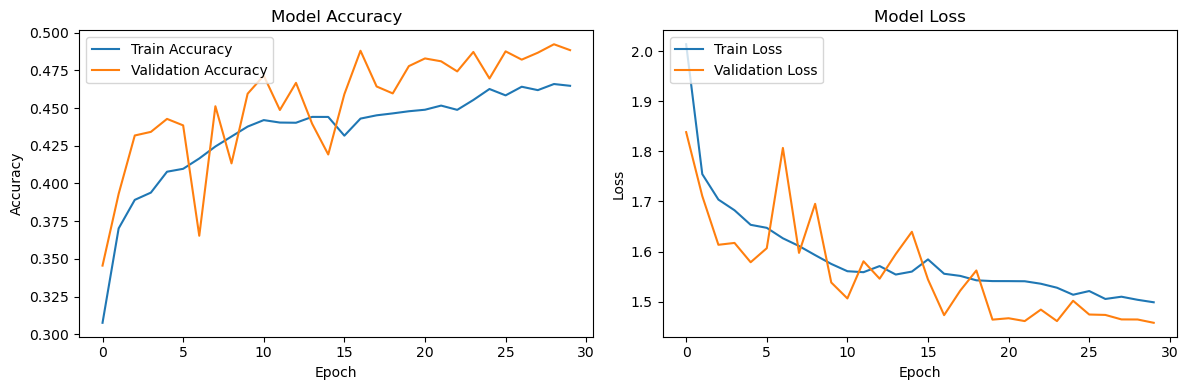

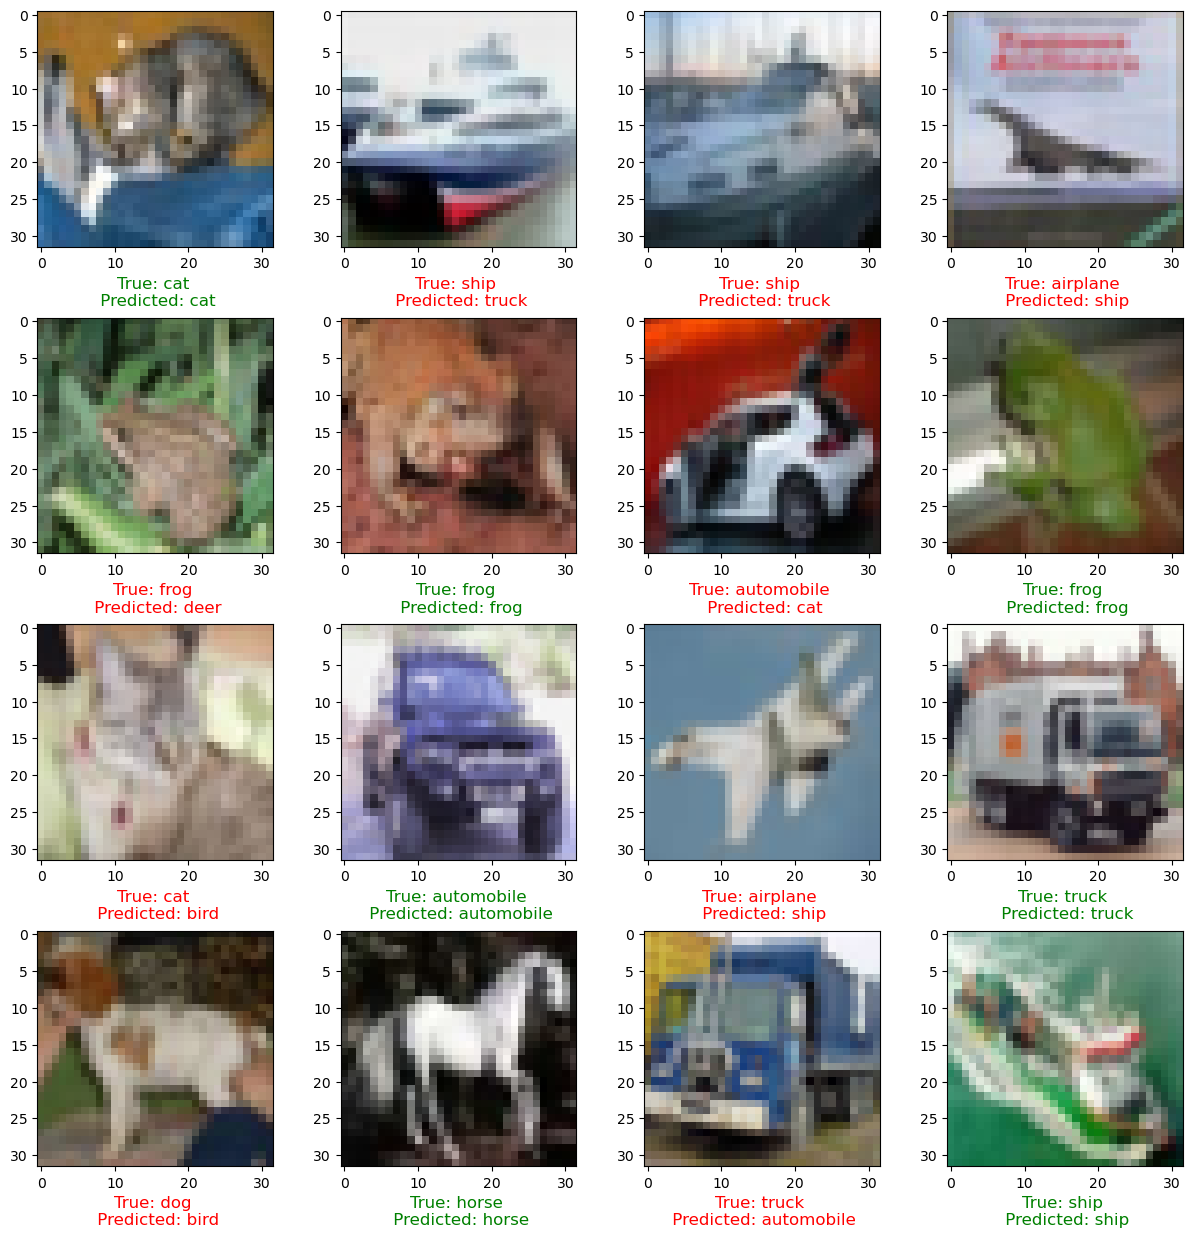

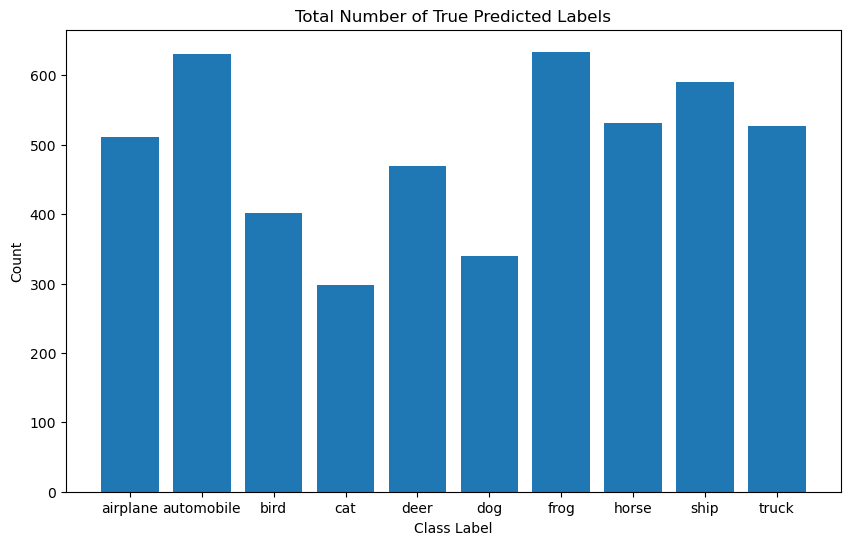

In [13]:
 # TODO

def main(epochs, val_split, batch_sz):
  """Main function to run the training pipeline.

    Args:
        epochs(int, optional): Number of epochs to train the model.
        val_split: Fraction of the training data to be used as validation data.
        batch_sz: Batch size for training.

    Returns:
        None

  """
  # (TODO)Preprocess the data
  x_train, x_test, y_train_oh, y_test_oh = data_preprocessing(X_train, X_test, y_train, y_test)

  # (TODO)Build Model
  model = build_model((x_train.shape[1],), y_train_oh.shape[1])

  compile_model(model)

  # (TODO)Compile model

  # Train model
  history = train_model(x_train, y_train_oh, model, epochs=epochs, val_split=val_split, batch_sz=batch_sz)

  test_loss, test_acc = model.evaluate(x_test, y_test_oh)
  print('Test accuracy:', test_acc)

  y_pred = model.predict(x_test)
  y_pred = np.argmax(y_pred, axis=1)
  y_true = np.argmax(y_test_oh, axis=1)

  # Plots
  plot_metrics(history)
  plot_predictions(X_test, y_true, y_pred, num_samples=16)
  plot_label_comparison(y_true, y_pred)

  test_model_accuracy(history=history)

  return history

if __name__ == "__main__":
    
    # (TODO) Feel free to adjust the parameters
    history = main(epochs=30, val_split=0.2, batch_sz=32)

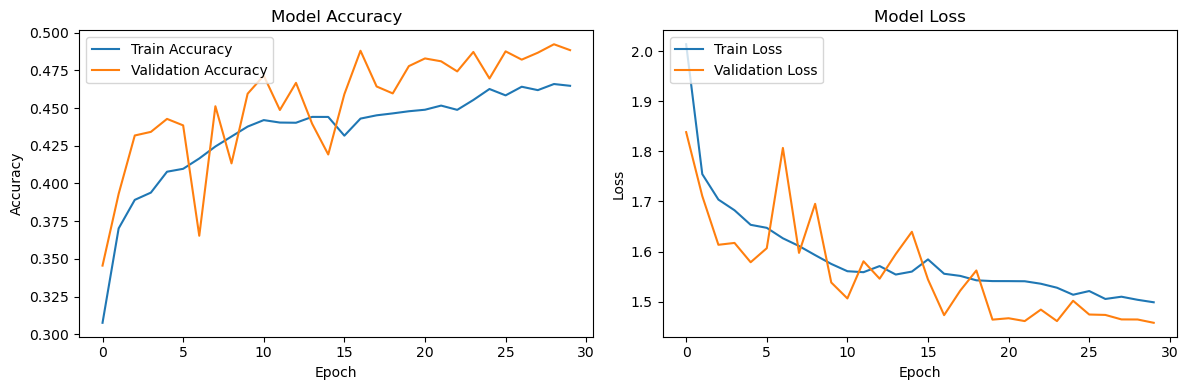

In [14]:
plot_metrics(history)